# Results

In [1]:
from sim_pipeline import *
from plot_helpers import *

import numpy as np

In [11]:

graph_kind = "er" # or er
lambdas=[0.3]
T_max = 10
N=12
d=3
deltas= [0.2]
rho_list = np.arange(0, 1.1, 0.1)
#rho_list = [0.3, 0.6]
Nsim = 2
track_sensor=True

param_list = [(delta, lam, rho) for delta in deltas for lam in lambdas for rho in rho_list]
# sensor selection method

methods = ["random", "greedyOV", "greedySampleReplaceOV"] #["random", "page_rank", "betweenness", "degree"] 
params = {"N": N, "d": d, "T_max": T_max, "Nsim": Nsim, "methods": methods, "param_list": param_list, "graph_kind": graph_kind, "track_sensor": track_sensor}

## Run new simulation

In [21]:
results_df, sensors_df = full_sim(params, Gfixed=False)

Running method random...


Simulations: 100%|██████████| 11/11 [00:00<00:00, 14.49it/s]


Running method greedyOV...


Simulations: 100%|██████████| 11/11 [00:06<00:00,  1.75it/s]


Running method greedySampleReplaceOV...


100%|██████████| 2/2 [00:00<00:00, 17.32it/s]

Results saved to results/methods_random_greedyOV_greedySampleReplaceOV_N12_d3_T10_Nsim2.csv


## Load previous simulation results

In [3]:
PATH = "./results/methods_random_page_rank_betweenness_degree_N500_d3_T10_Nsim10.csv"
results_df = pd.read_csv(PATH)

In [4]:
random_results_df = results_df[results_df["method"] == "random"]
pagerank_results_df = results_df[results_df["method"] == "page_rank"]
betweenness_results_df = results_df[results_df["method"] == "betweenness"]
degree_results_df = results_df[results_df["method"] == "degree"]
greedyOV_results_df = results_df[results_df["method"] == "greedyOV"]

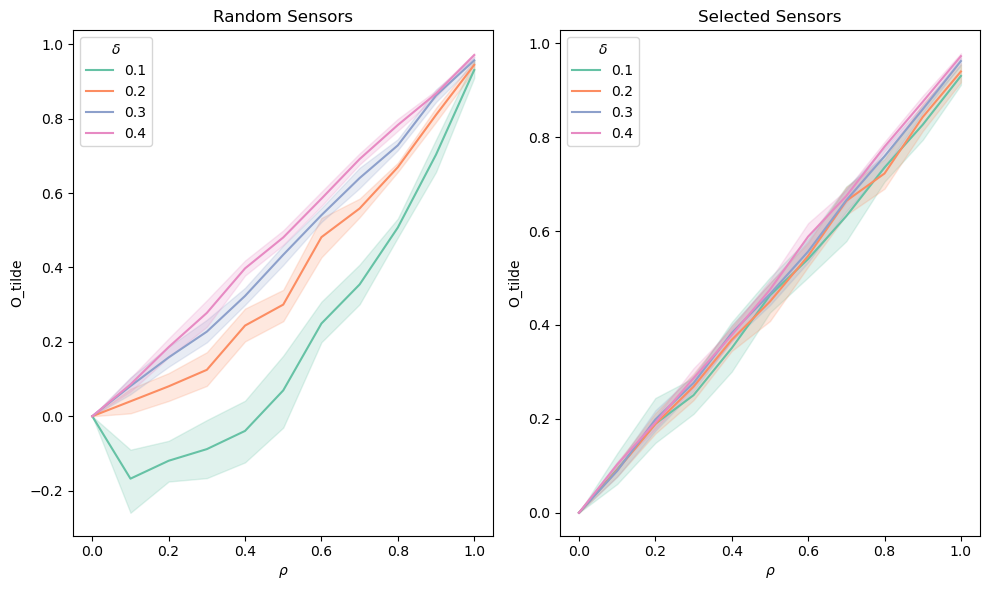

In [8]:
plot_side_by_side(random_results_df, degree_results_df, metric="O_tilde")

In [5]:
plot_comparison(results_df, delta=deltas[0], metric="O_tilde")

NameError: name 'deltas' is not defined

In [23]:
sensors_greedyOV_df = sensors_df[sensors_df["method"] == "greedyOV"]
sensors_greedySubsetOV_df = sensors_df[sensors_df["method"] == "greedySubsetOV"]

In [24]:
sensors_greedyOV_df.head()

,sim,method,graph_kind,N,d,delta,lam,rho,k,subset_size,mean_pairwise_distance,boundary_size,density,mean_degree,degree_bias
0,0,greedyOV,er,12,3,0.2,0.3,0.0,0,0,NaN,0,0.000000,NaN,NaN
1,0,greedyOV,er,12,3,0.2,0.3,0.1,1,1,NaN,3,0.000000,3.00,0.900
2,0,greedyOV,er,12,3,0.2,0.3,0.2,2,2,1.000000,5,1.000000,4.50,1.350
3,0,greedyOV,er,12,3,0.2,0.3,0.3,3,3,1.333333,5,0.666667,4.00,1.200
4,0,greedyOV,er,12,3,0.2,0.3,0.4,4,4,1.333333,6,0.666667,4.25,1.275


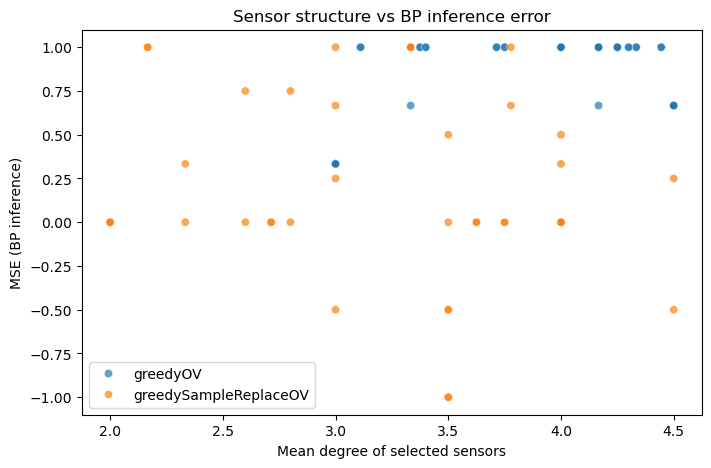

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

merged_df = pd.merge(results_df, sensors_df, on=["method", "delta", "rho"], how="inner")

sns.scatterplot(
    data=merged_df,   # sensors_df merged with results_df
    x="mean_degree",  # or "degree", "page_rank"
    y="O_tilde",
    hue="method",
    alpha=0.7
)

plt.title("Sensor structure vs BP inference error")
plt.xlabel("Mean degree of selected sensors")
plt.ylabel("MSE (BP inference)")
plt.legend()
plt.show()